In [3]:
# ====================
# 1. KONFIGURASI & SETUP
# ====================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import seaborn as sns
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

# Setup plotting
plt.style.use('default')
sns.set_style("whitegrid")

@dataclass
class TankConfig:
    """Konfigurasi parameter sistem water tank"""
    # Parameter Fisik Tanki (Silinder)
    radius: float = 1.5              # meter
    max_height: float = 5.0          # meter
    initial_level: float = 0.5       # meter (level air awal)
    
    # Parameter Aliran (Inlet & Outlet)
    inflow_rate: float = 0.05        # m³/detik (kapasitas pompa masuk)
    pipe_radius: float = 0.1         # meter (jari-jari pipa pengeluaran)
    gravity: float = 9.81            # m/s²
    discharge_coeff: float = 0.6     # koefisien gesekan outlet (Cd)
    
    # Parameter Simulasi
    simulation_time: float = 60.0    # menit
    time_step: float = 1.0           # detik
    
    # Status Operasional
    pump_on: bool = True             # Apakah pompa pengisi menyala?
    valve_open: bool = True          # Apakah keran distribusi dibuka?
    
    # Atribut yang dihitung
    surface_area: float = field(init=False)
    max_volume: float = field(init=False)
    
    def __post_init__(self):
        """Hitung luas permukaan dan volume maksimal"""
        self.surface_area = np.pi * (self.radius ** 2)
        self.max_volume = self.surface_area * self.max_height
    
    def copy(self):
        params = {k: v for k, v in self.__dict__.items() 
                 if k not in ['surface_area', 'max_volume']}
        return TankConfig(**params)
    
    def update_parameter(self, parameter_name: str, value: float):
        if hasattr(self, parameter_name):
            setattr(self, parameter_name, value)
            self.__post_init__()
        else:
            raise ValueError(f"Parameter {parameter_name} tidak valid")

print("KONFIGURASI & SETUP TANKI AIR")

KONFIGURASI & SETUP TANKI AIR


In [4]:
# ====================
# 2. MODEL FISIKA
# ====================

class PhysicsModel:
    """Model fisika untuk dinamika fluida dalam tanki"""
    
    def __init__(self, config: TankConfig):
        self.config = config
    
    def calculate_inflow(self) -> float:
        """Menghitung debit air masuk (m³/s)"""
        return self.config.inflow_rate if self.config.pump_on else 0.0
    
    def calculate_outflow(self, current_height: float) -> float:
        """Menghitung debit air keluar berdasarkan Hukum Torricelli"""
        if not self.config.valve_open or current_height <= 0:
            return 0.0
        
        # v = sqrt(2gh)
        velocity = np.sqrt(2 * self.config.gravity * current_height)
        pipe_area = np.pi * (self.config.pipe_radius ** 2)
        
        # Q = Cd * A * v
        return self.config.discharge_coeff * pipe_area * velocity

print("MODEL FISIKA FLUIDA")

MODEL FISIKA FLUIDA


In [5]:
# ====================
# 3. SISTEM PERSAMAAN DIFERENSIAL
# ====================

class DifferentialEquations:
    """Persamaan perubahan ketinggian air: dh/dt = (Qin - Qout) / Area"""
    
    def __init__(self, physics_model: PhysicsModel):
        self.physics = physics_model
        self.config = physics_model.config
    
    def system_equations(self, t: float, y: np.ndarray) -> np.ndarray:
        h = max(0.0, y[0])  # Ketinggian air tidak bisa negatif
        
        # Cek apakah air meluap (overflow)
        if h >= self.config.max_height:
            # Jika penuh, inflow dianggap terbuang atau pompa mati otomatis
            q_in = 0.0 if self.physics.calculate_inflow() > self.physics.calculate_outflow(h) else self.physics.calculate_inflow()
        else:
            q_in = self.physics.calculate_inflow()
            
        q_out = self.physics.calculate_outflow(h)
        
        # dh/dt = (Q_net) / Luas Permukaan
        dh_dt = (q_in - q_out) / self.config.surface_area
        
        # Stop jika tanki kosong dan Qout > Qin
        if h <= 0 and dh_dt < 0:
            dh_dt = 0
            
        return np.array([dh_dt])

print("SISTEM PERSAMAAN DIFERENSIAL (dh/dt)")

SISTEM PERSAMAAN DIFERENSIAL (dh/dt)


In [6]:
# ====================
# 4. SIMULATOR UTAMA
# ====================

class WaterTankSimulator:
    def __init__(self, config: TankConfig):
        self.config = config
        self.physics = PhysicsModel(config)
        self.equations = DifferentialEquations(self.physics)
        self.results = {}
    
    def run_simulation(self) -> Dict:
        t_span = (0, self.config.simulation_time * 60)
        t_eval = np.arange(0, self.config.simulation_time * 60, self.config.time_step)
        
        solution = solve_ivp(
            fun=self.equations.system_equations,
            t_span=t_span,
            y0=[self.config.initial_level],
            t_eval=t_eval,
            method='RK45'
        )
        
        self.time_history = solution.t / 60.0  # Menit
        self.height_history = solution.y[0]
        self.volume_history = self.height_history * self.config.surface_area
        
        self.results = self._calculate_metrics()
        return self.results
    
    def _calculate_metrics(self) -> Dict:
        return {
            'initial_height': self.height_history[0],
            'final_height': self.height_history[-1],
            'max_height_reached': np.max(self.height_history),
            'final_volume': self.volume_history[-1],
            'is_full': self.height_history[-1] >= (self.config.max_height * 0.99),
            'is_empty': self.height_history[-1] <= 0.05
        }

print("SIMULATOR WATER TANK")

SIMULATOR WATER TANK


In [7]:
# ====================
# 5. VISUALISASI
# ====================

class Visualization:
    @staticmethod
    def plot_tank_profile(simulator: WaterTankSimulator):
        fig, ax1 = plt.subplots(figsize=(10, 6))
        
        ax1.plot(simulator.time_history, simulator.height_history, 'b-', label='Level Air (m)')
        ax1.axhline(y=simulator.config.max_height, color='r', linestyle='--', label='Kapasitas Maksimal')
        ax1.fill_between(simulator.time_history, 0, simulator.height_history, color='skyblue', alpha=0.4)
        
        ax1.set_xlabel('Waktu (menit)')
        ax1.set_ylabel('Ketinggian Air (meter)')
        ax1.set_title('Dinamika Level Air dalam Tanki')
        ax1.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.show()

print("VISUALISASI SIAP")

VISUALISASI SIAP


=== SKENARIO 1: PENGISIAN PENUH (Outlet Tutup) ===


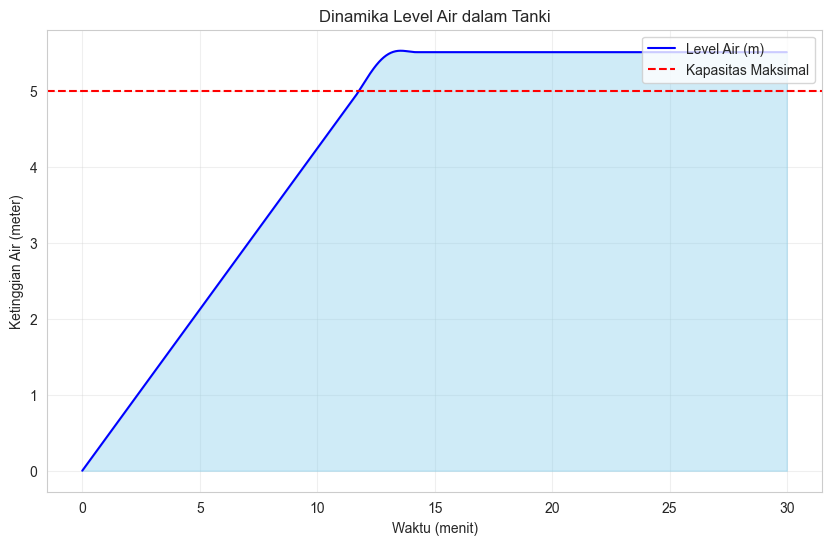

Ketinggian Akhir: 5.51 m

=== SKENARIO 2: PENGOSONGAN (Pompa Mati) ===


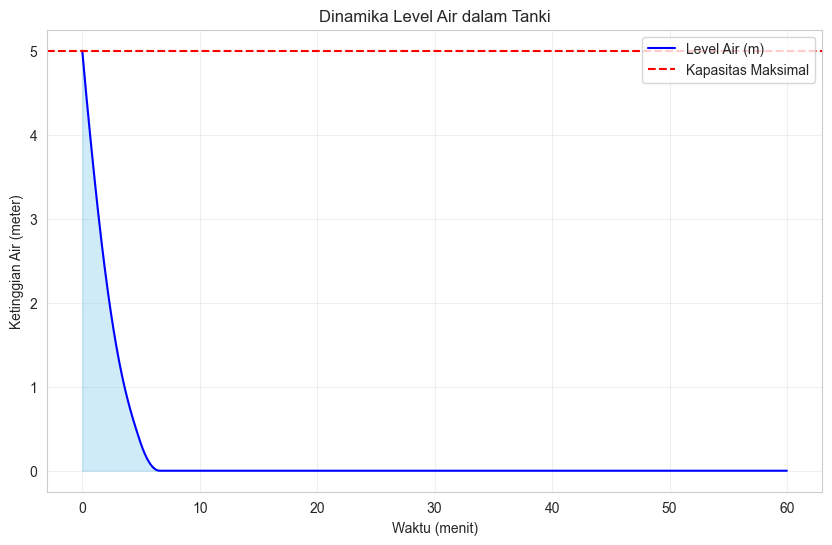


=== SKENARIO 3: DINAMIKA BERSAMAAN (Inlet & Outlet Buka) ===


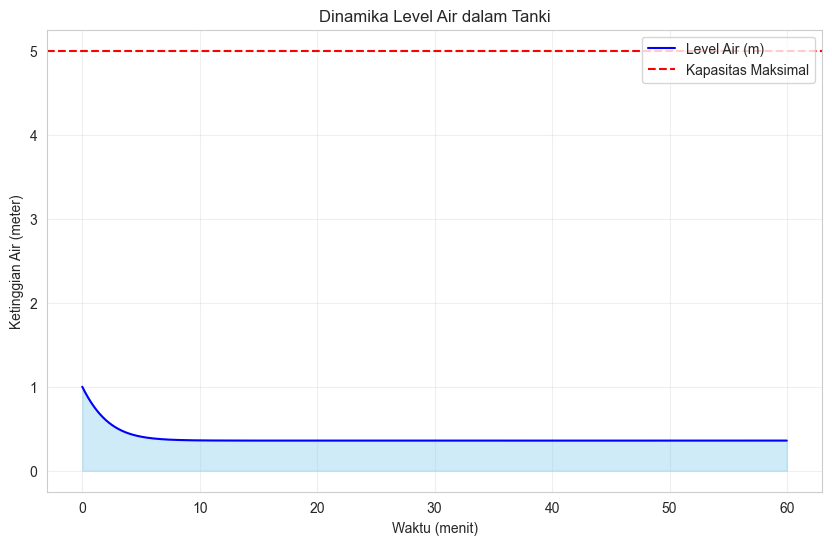

In [8]:
# ====================
# 6. RUN SIMULATION
# ====================

def main():
    print("=== SKENARIO 1: PENGISIAN PENUH (Outlet Tutup) ===")
    config_fill = TankConfig(initial_level=0.0, valve_open=False, simulation_time=30.0)
    sim_fill = WaterTankSimulator(config_fill)
    sim_fill.run_simulation()
    Visualization.plot_tank_profile(sim_fill)
    
    print(f"Ketinggian Akhir: {sim_fill.results['final_height']:.2f} m")
    
    print("\n=== SKENARIO 2: PENGOSONGAN (Pompa Mati) ===")
    config_drain = TankConfig(initial_level=5.0, pump_on=False, valve_open=True, simulation_time=60.0)
    sim_drain = WaterTankSimulator(config_drain)
    sim_drain.run_simulation()
    Visualization.plot_tank_profile(sim_drain)

    print("\n=== SKENARIO 3: DINAMIKA BERSAMAAN (Inlet & Outlet Buka) ===")
    config_both = TankConfig(initial_level=1.0, pump_on=True, valve_open=True, simulation_time=60.0)
    sim_both = WaterTankSimulator(config_both)
    sim_both.run_simulation()
    Visualization.plot_tank_profile(sim_both)

if __name__ == "__main__":
    main()